In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from feature_engine.imputation import MeanMedianImputer, RandomSampleImputer

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from feature_engine.encoding import OneHotEncoder

from sklearn.preprocessing import QuantileTransformer

from sklearn.preprocessing import (
                                    MinMaxScaler,
                                    StandardScaler,
                                    RobustScaler,
                                    Normalizer,
                                    PowerTransformer,
                                    QuantileTransformer
                                    )

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression,f_regression, SelectKBest

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

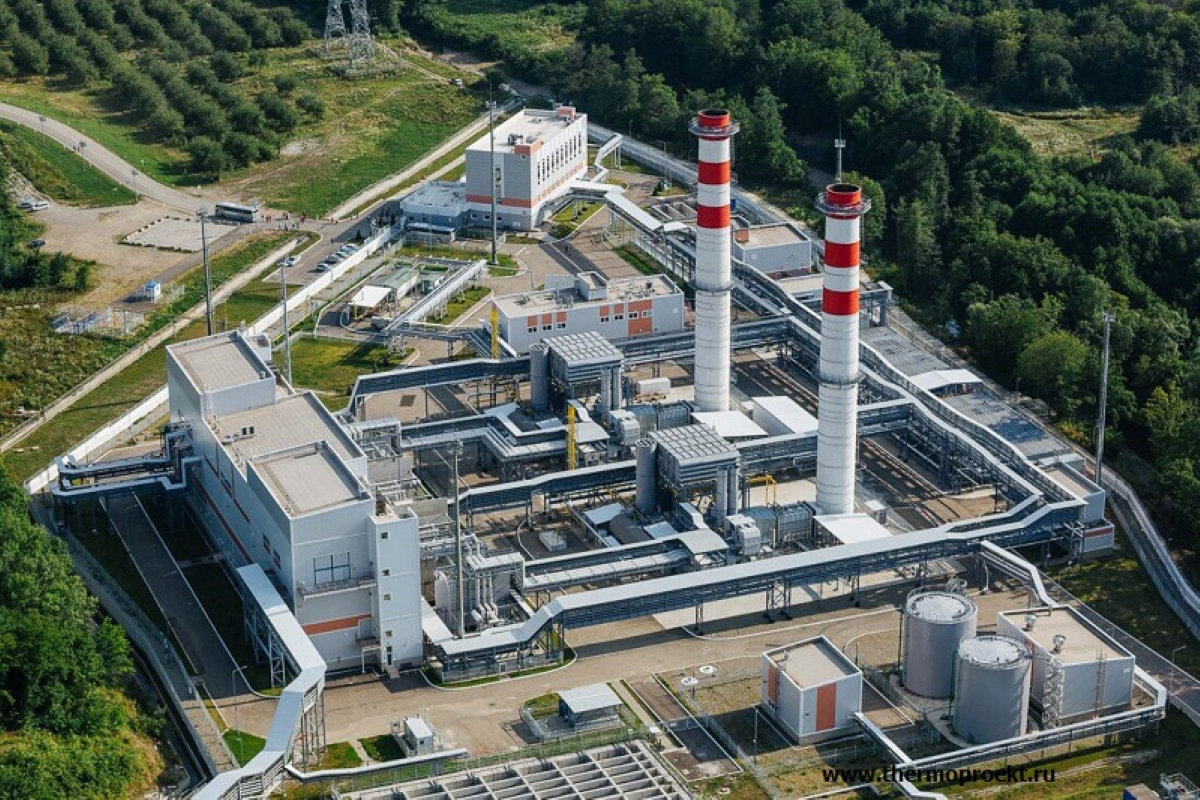

# Combined Cycle Power Plant (CCPP)

В оригинале он содержит данные о работе газотурбинной электростанции и используется для регрессии — предсказания электрической мощности по параметрам окружающей среды.

## AT — ambient temperature
Температура окружающей среды на входе компрессора газовой турбины.

Единицы: °C.

Физический смысл:
- Более высокая температура уменьшает плотность воздуха, снижает массовый расход через компрессор и, как следствие, доступную мощность и КПД цикла.

Ожидаемый знак влияния на PE: Отрицательный: рост AT → падение PE.

Тип связи: 
- Часто квазилинейная у локальных диапазонов; возможна слаболинейная или слегка выпуклая зависимость. При экстремальных температурах влияние усиливается из‑за ограничений компрессора.

Взаимодействия:

- С AP: при одинаковой температуре более высокое давление частично компенсирует потерю плотности.

- С RH: при высокой влажности эффективная плотность воздуха слегка снижается, но есть и охлаждающий эффект в некоторых системах охлаждения впуска.

Предобработка и проверки:

- Диапазоны: Обнаружить выбросы и неверные единицы (например, °F).

- Линейность: Проверить необходимость нелинейных признаков: AT2, сплайны, биннинг по сезонам.



## V — exhaust vacuum
Определение: Вакуум на выходе конденсатора паровой турбины (уровень разрежения).

Единицы: cm Hg.

Физический смысл:
- Чем выше вакуум (большее разрежение), тем ниже противодавление на выходе турбины, тем выше пригодная к извлечению работа — это повышает мощность.

Ожидаемый знак влияния на PE: 
- Положительный: рост V → рост PE.

Тип связи: 
- Часто квазилинейная или умеренно нелинейная, с убывающей отдачей при очень высоком вакууме (приближение к физическим пределам).

Взаимодействия:
- С RH и AT: влияют на эффективность конденсации, меняя достижимый вакуум.
- С AP: влияет через насыщение/конденсацию и теплообмен с окружающей средой.

Предобработка и проверки:
- Физические границы: Невозможны отрицательные значения; проверить смещённые шкалы.

- Возможна сезонность через качество охлаждающей воды/воздуха.

## AP — ambient pressure
Определение: Атмосферное давление на площадке.

Единицы: mbar.

Физический смысл:
- Более высокое давление повышает плотность воздуха, увеличивая массовый расход через компрессор и мощность. Также влияет на кипение/конденсацию в хвостовой части цикла.

Ожидаемый знак влияния на PE: 
- Положительный: рост AP → рост PE.

Тип связи: 
- Близка к линейной в узких диапазонах, но эффект зависит от AT (через плотность).

Взаимодействия:
- С AT: ключевое сочетание через газовую плотность; полезно рассмотреть отношение (AP / AT+273.15) как прокси плотности.

Предобработка и проверки:

- Высота над уровнем моря: Если доступны координаты, можно проверять соответствие ожидаемому диапазону давления.

- Нормализация по погодным сдвигам или сезонной волатильности.

Визуализация:

- Scatter: AP vs PE; 2D-heatmap/contour: AP × AT → PE.

## RH — relative humidity
Определение: Относительная влажность окружающего воздуха.

Единицы: %.

Физический смысл: 
- Водяной пар легче сухого воздуха; при росте RH уменьшается плотность сухого воздуха при прочих равных, что слегка снижает массовый расход. В некоторых условиях впрыск/испарительное охлаждение повышает эффективность, смягчая эффект.

Ожидаемый знак влияния на PE: 
- Чаще слабонегативный, но может быть нейтральным или неоднозначным в зависимости от AT и конфигурации станции.

Тип связи: 
- Нелинейная; влияние заметнее при высокой AT.

Взаимодействия:
- С AT: при жаре высокий RH ухудшает условия на впуске и конденсацию.
- С V: RH влияет на конденсатор и достижимый вакуум.

Предобработка и проверки:
- Проверить границы 0–100; обрезать/исправлять артефакты >100 или <0.
- Возможны суточные и сезонные паттерны.

Визуализация:
Conditional plots: RH vs PE при фиксированных квантилях AT.

## PE — net hourly electrical energy output
Целевая переменная — часовая электрическая мощность на выходе станции при полной нагрузке.

Единицы: MW.

Ожидаемая зависимость:
- Убывает с AT.
- Растёт с AP и V.

Слабо убывает или слабо зависит от RH.

Диагностика:
- Стабильность дисперсии: проверить гетероскедастичность остатков для линейных моделей.

- Сезонность: возможны сезонные сдвиги; добавить календарные признаки, если доступны даты.

Инженерия признаков:
Плотность воздуха:
𝜌
≈
AP
𝑅
⋅
(
AT
+
273.15
)
Можно добавить 
𝜌
 или лог-плотность как признак.

Нелинейности: квадратичные термы и взаимодействия: 
AT
2
,
 AP
 ⁣
:
 ⁣
AT
,
 RH
 ⁣
:
 ⁣
AT
.

Нормализация: масштабирование признаков полезно для линейных/регуляризованных и нейросетей.

In [2]:
# Замените 'your_file.xlsx' на путь к вашему файлу
data_origin = pd.read_excel('Folds5x2_pp_TP.xlsx', engine='openpyxl')
display(data_origin.head())
data_origin.shape

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


(9568, 5)

||||
|-|-|-|
|AT|Температура окружающей среды|°C|
|V|Вакуум на выходе конденсатора паровой турбины|мм рт. ст. или мбар
|AP|Атмосферное давление на площадке|мбар
|RH|Относительная влажность окружающего воздуха|%
|PE|Выходная электрическая мощность (целевая переменная)|МВт

In [3]:
data_origin.describe()

,AT,V,AP,RH,PE
count,9525.000000,9533.000000,9503.000000,9510.000000,9568.000000
mean,19.641594,54.311154,1013.250053,73.291181,454.365009
std,7.454601,12.705674,5.934166,14.593837,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.090000,63.320000,439.750000
50%,20.320000,52.080000,1012.930000,74.955000,451.550000
75%,25.720000,66.540000,1017.250000,84.810000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [4]:
data_origin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9525 non-null   float64
 1   V       9533 non-null   float64
 2   AP      9503 non-null   float64
 3   RH      9510 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


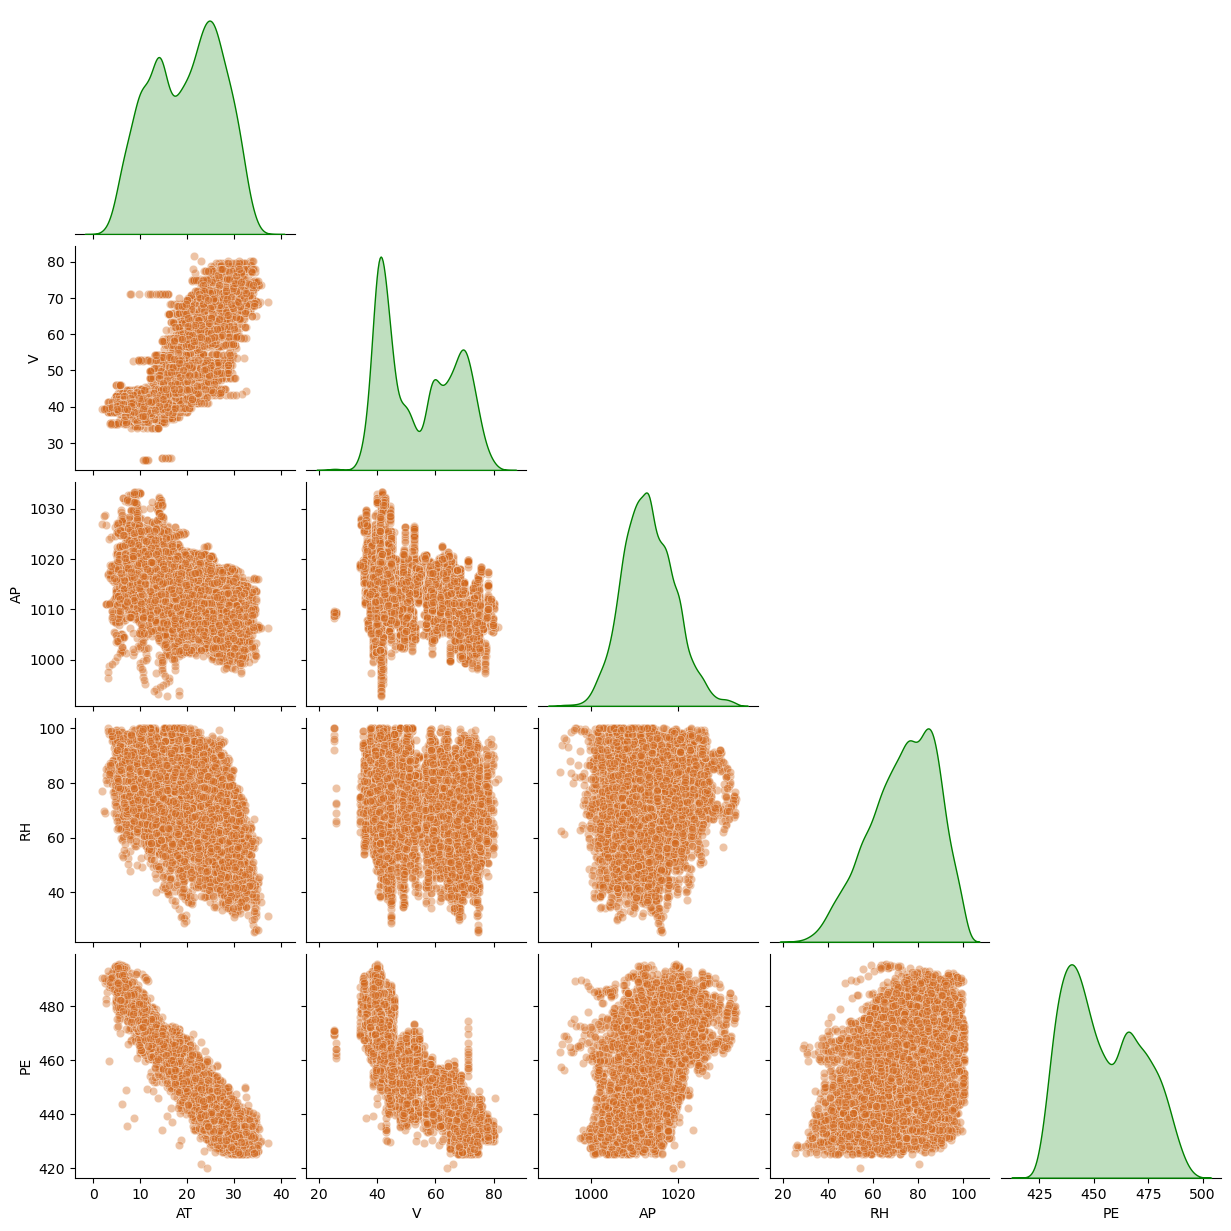

In [5]:
sns.pairplot(data_origin, diag_kind='kde', corner=True, 
             plot_kws={'color': 'Chocolate', 'alpha': 0.4},
             diag_kws={'color': 'green'})
plt.show()

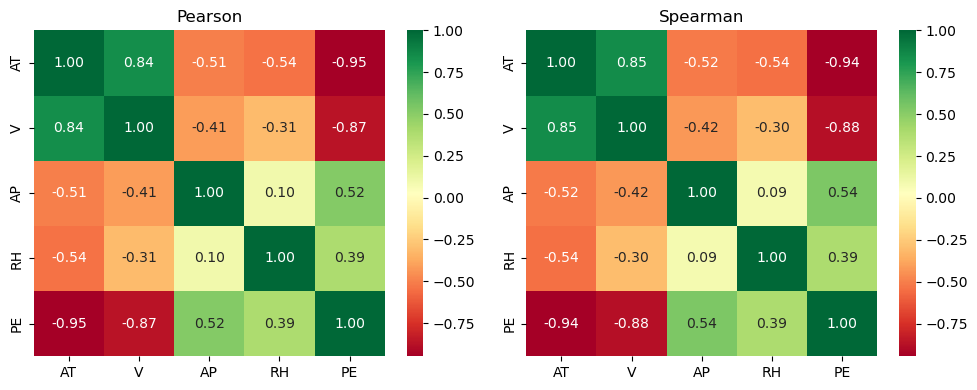

In [6]:
plt.figure(figsize=(10, 4))
# 1. Пирсон
plt.subplot(1, 2, 1)
sns.heatmap(data_origin.corr(method="pearson"), annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Pearson")

# 2. Спирмен
plt.subplot(1, 2, 2)
sns.heatmap(data_origin.corr(method="spearman"), annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Spearman")

plt.tight_layout()
plt.show()

## Missing Value

In [7]:
missing_data = (pd.concat([data_origin.isna().sum(), data_origin.isna().mean() * 100], keys = ['count','%'], axis = 1)).sort_values(ascending=False, by='count')
missing_data = missing_data[missing_data['count'] > 0]
missing_data

,count,%
AP,65,0.679348
RH,58,0.606187
AT,43,0.449415
V,35,0.365803


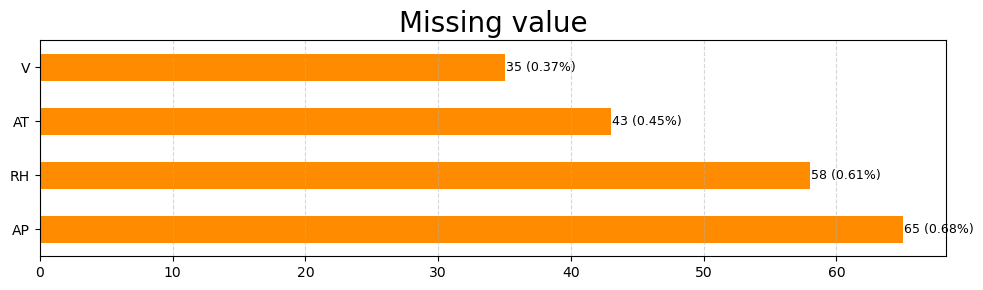

In [8]:
plt.figure(figsize=(10, 3))
ax = missing_data['count'].plot.barh(color='DarkOrange')

for i, bar in enumerate(ax.containers[0]):
    count = int(bar.get_width())
    percent = missing_data['%'].iloc[i]
    label = f"{count} ({percent:.2f}%)"
    
    ax.text(
        count + 0.1,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center',
        fontsize=9,
        color='black'
    )

plt.title('Missing value' ,fontsize=20)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [9]:
def check_missing_mechanism(df):
    results = []

    for col in df.columns:
        if df[col].isna().sum() > 0:  # только для признаков с пропусками
            missing_idx = df[col].isna()
            for other_col in df.columns:
                if other_col != col:
                    # сравниваем распределения других признаков
                    group_missing = df.loc[missing_idx, other_col].dropna()
                    group_nonmissing = df.loc[~missing_idx, other_col].dropna()

                    if group_missing.empty or group_nonmissing.empty:
                        continue

                    # t-test для числовых
                    t_stat, p_val = stats.ttest_ind(group_missing, group_nonmissing, nan_policy='omit')
                    results.append({
                        "target_with_missing": col,
                        "tested_against": other_col,
                        "p_value": p_val
                    })
    return pd.DataFrame(results)

results = check_missing_mechanism(data_origin)
print(results.sort_values(by='p_value'))

   target_with_missing tested_against   p_value
13                  RH              V  0.002315
15                  RH             PE  0.002599
12                  RH             AT  0.013429
14                  RH             AP  0.013436
0                   AT              V  0.018164
3                   AT             PE  0.047517
7                    V             PE  0.051403
5                    V             AP  0.060226
2                   AT             RH  0.073809
4                    V             AT  0.093321
6                    V             RH  0.219823
9                   AP              V  0.265131
1                   AT             AP  0.367500
8                   AP             AT  0.554489
11                  AP             PE  0.610037
10                  AP             RH  0.760231


In [10]:
data_temp = data_origin.copy()

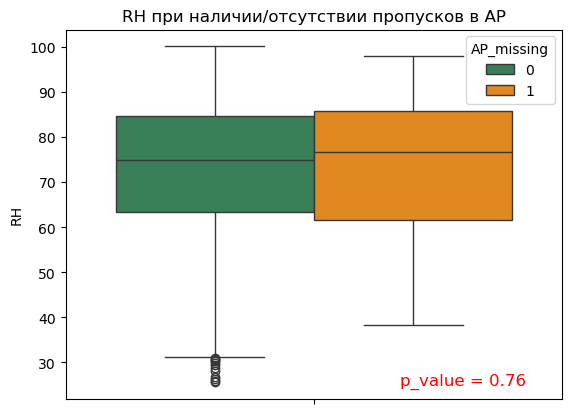

In [11]:
data_temp['AP_missing'] = data_temp['AP'].isna().astype(int)

sns.boxplot(hue='AP_missing', y='RH', data=data_temp, palette=['SeaGreen', 'DarkOrange'])
plt.title("RH при наличии/отсутствии пропусков в AP")

plt.text(0.3, 25, 'p_value = 0.76', ha='center', fontsize=12, color='red')
plt.show()

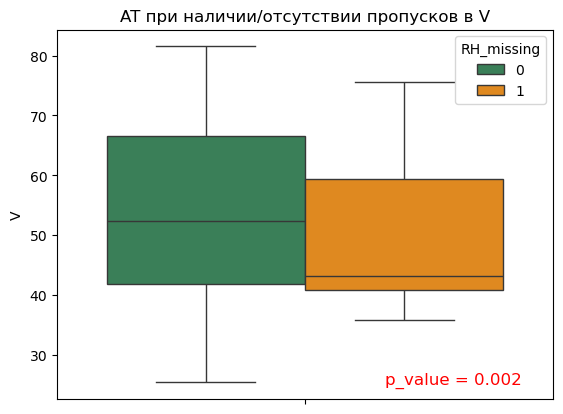

In [12]:
data_temp['RH_missing'] = data_temp['RH'].isna().astype(int)

sns.boxplot(hue='RH_missing', y='V', data=data_temp, palette=['SeaGreen', 'DarkOrange'])
plt.title("AT при наличии/отсутствии пропусков в V")

plt.text(0.3, 25, 'p_value = 0.002', ha='center', fontsize=12, color='red')
plt.show()

## Missing Value impute test

In [13]:
def generate_imputations(data):
    """
    Применяет 5 методов импутации ко всем признакам.
    Возвращает словарь с восстановленными версиями.
    """
    features = [col for col in data.columns]
    df_subset = data[features].copy()

    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_subset), columns=features)

    imputed_versions = {}

    # Mean
    mean_imputer = MeanMedianImputer(imputation_method='mean', variables=features)
    imputed_versions['Mean'] = mean_imputer.fit_transform(df_subset)

    # Median
    median_imputer = MeanMedianImputer(imputation_method='median', variables=features)
    imputed_versions['Median'] = median_imputer.fit_transform(df_subset)

    # Random Sample
    random_imputer = RandomSampleImputer(variables=features, random_state=42)
    imputed_versions['Random'] = random_imputer.fit_transform(df_subset)

    # KNN
    knn_imputer = KNNImputer(n_neighbors=5)
    knn_imputed = pd.DataFrame(knn_imputer.fit_transform(df_scaled), columns=features)
    imputed_versions['KNN'] = pd.DataFrame(scaler.inverse_transform(knn_imputed), columns=features)

    # Iterative
    iter_imputer = IterativeImputer(estimator=LinearRegression(), max_iter=10, random_state=42)
    iter_imputed = pd.DataFrame(iter_imputer.fit_transform(df_scaled), columns=features)
    imputed_versions['Iterative'] = pd.DataFrame(scaler.inverse_transform(iter_imputed), columns=features)

    return imputed_versions

def analyze_imputation(variable, original_df, imputed_versions):
    """
    Строит график распределений и сравнивает дисперсии для выбранной переменной.
    """
    plt.figure(figsize=(12, 6))
    sns.kdeplot(original_df[variable], label='Original (missing values)', color='black', linewidth=2)

    variances = {}
    original_var = original_df[variable].var()

    for method, restored_df in imputed_versions.items():
        sns.kdeplot(restored_df[variable], label=f'{method} Imputation', linewidth=2)
        var = restored_df[variable].var()
        variances[method] = var

    plt.title(f"{variable} variance after imputation.")
    plt.xlabel(variable)
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\n📊 Дисперсия оригинального {variable}: {original_var:.4f}")
    for method, var in variances.items():
        print(f"Дисперсия после {method} Imputation: {var:.4f} (Δ = {abs(original_var - var):.4f})")

    best_method = min(variances, key=lambda k: abs(variances[k] - original_var))
    best_diff = abs(variances[best_method] - original_var)

    print(f"\n✅ Наилучшее совпадение с оригинальной дисперсией: {best_method}. Разница: {best_diff:.4f}.")

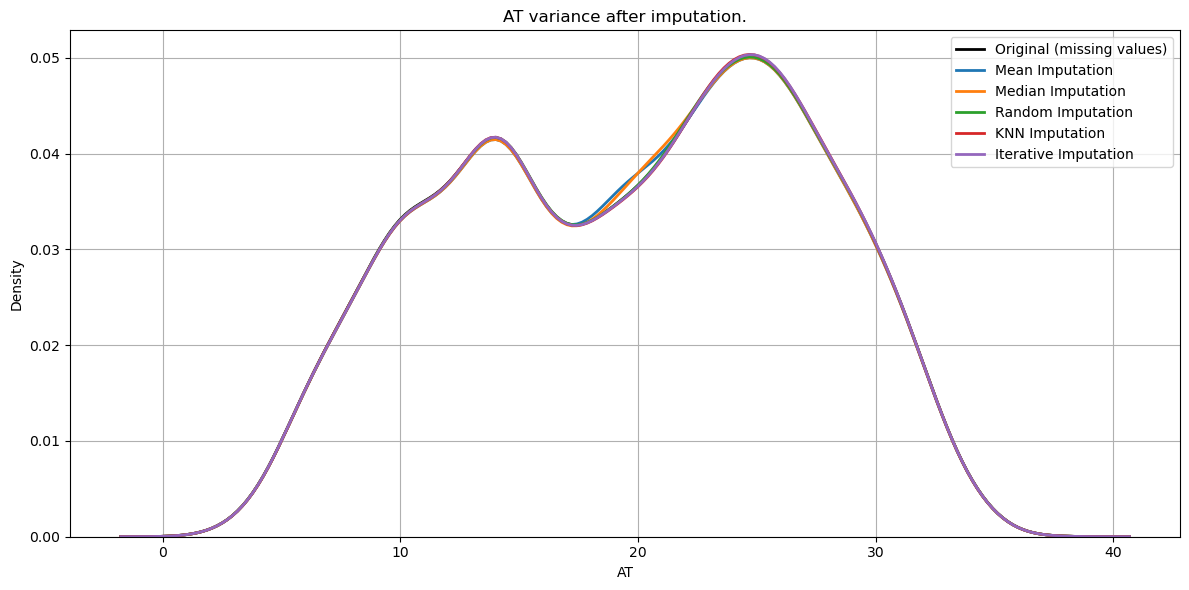


📊 Дисперсия оригинального AT: 55.5711
Дисперсия после Mean Imputation: 55.3213 (Δ = 0.2498)
Дисперсия после Median Imputation: 55.3234 (Δ = 0.2477)
Дисперсия после Random Imputation: 55.5443 (Δ = 0.0268)
Дисперсия после KNN Imputation: 55.5459 (Δ = 0.0252)
Дисперсия после Iterative Imputation: 55.5464 (Δ = 0.0247)

✅ Наилучшее совпадение с оригинальной дисперсией: Iterative. Разница: 0.0247.


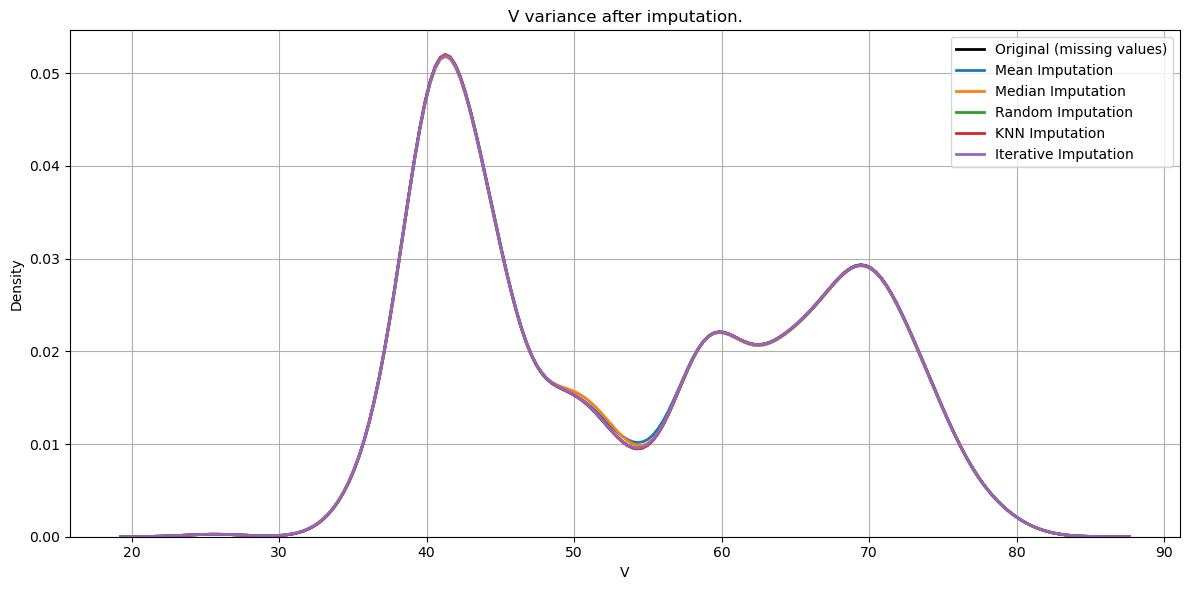


📊 Дисперсия оригинального V: 161.4342
Дисперсия после Mean Imputation: 160.8436 (Δ = 0.5906)
Дисперсия после Median Imputation: 160.8617 (Δ = 0.5724)
Дисперсия после Random Imputation: 161.4021 (Δ = 0.0321)
Дисперсия после KNN Imputation: 161.4455 (Δ = 0.0114)
Дисперсия после Iterative Imputation: 161.3398 (Δ = 0.0944)

✅ Наилучшее совпадение с оригинальной дисперсией: KNN. Разница: 0.0114.


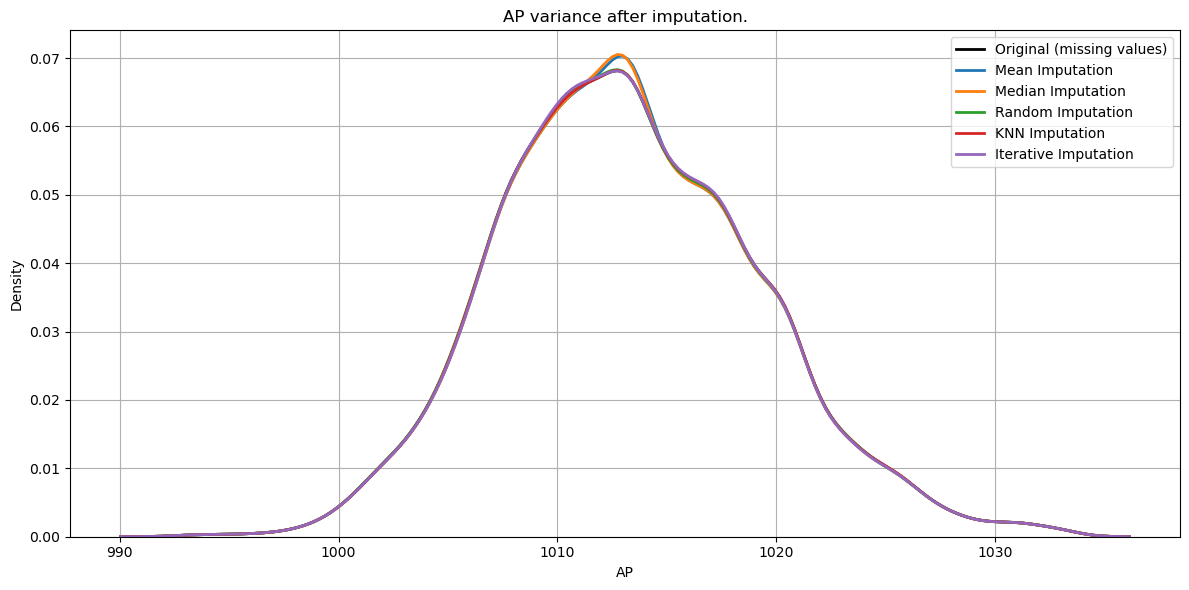


📊 Дисперсия оригинального AP: 35.2143
Дисперсия после Mean Imputation: 34.9751 (Δ = 0.2393)
Дисперсия после Median Imputation: 34.9758 (Δ = 0.2386)
Дисперсия после Random Imputation: 35.1859 (Δ = 0.0284)
Дисперсия после KNN Imputation: 35.1510 (Δ = 0.0633)
Дисперсия после Iterative Imputation: 35.0515 (Δ = 0.1628)

✅ Наилучшее совпадение с оригинальной дисперсией: Random. Разница: 0.0284.


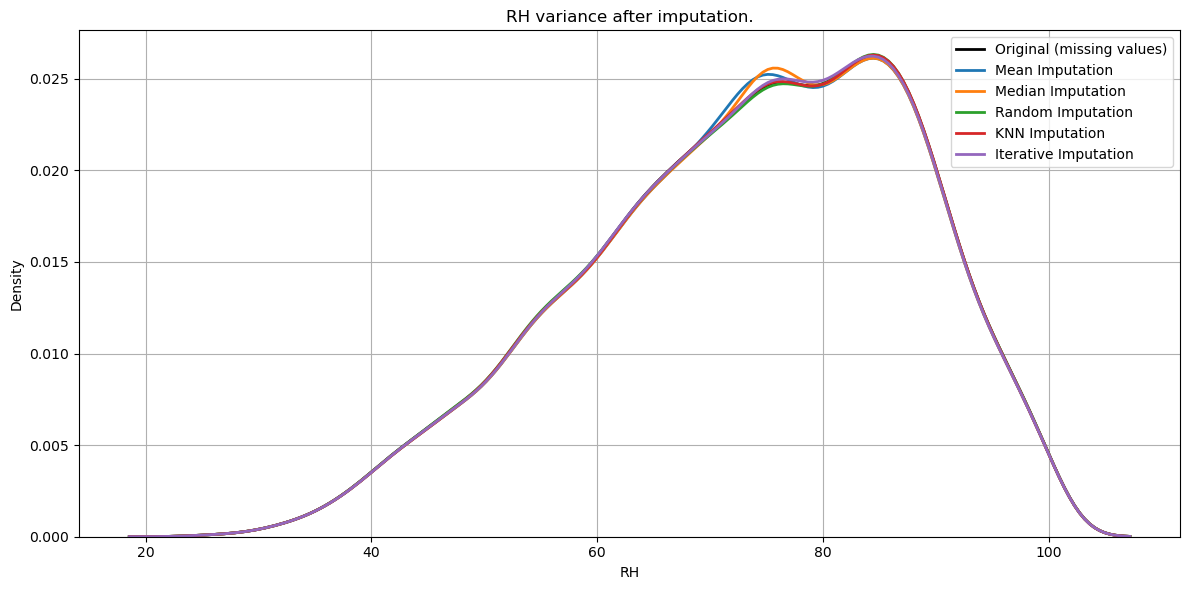


📊 Дисперсия оригинального RH: 212.9801
Дисперсия после Mean Imputation: 211.6889 (Δ = 1.2912)
Дисперсия после Median Imputation: 211.7056 (Δ = 1.2745)
Дисперсия после Random Imputation: 213.2277 (Δ = 0.2477)
Дисперсия после KNN Imputation: 212.5545 (Δ = 0.4256)
Дисперсия после Iterative Imputation: 212.2231 (Δ = 0.7569)

✅ Наилучшее совпадение с оригинальной дисперсией: Random. Разница: 0.2477.


In [14]:
imputed_versions = generate_imputations(data_origin)
for col in data_origin:
    if col != 'PE':
        analyze_imputation(col, data_origin, imputed_versions)

### PE (target)

<Axes: xlabel='PE', ylabel='Count'>

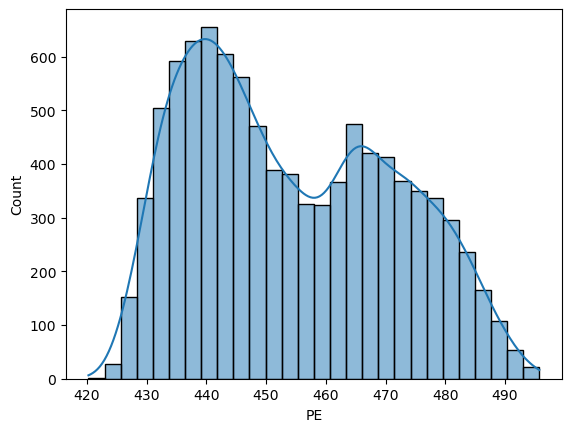

In [15]:
sns.histplot(data_origin['PE'], kde=True, edgecolor='black')

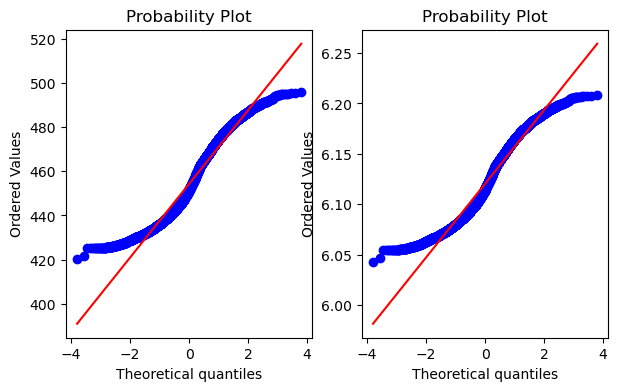

In [16]:
from scipy import stats 

fig = plt.figure(figsize = (7,4))

# Распределение на необработанных данных
fig.add_subplot(1,2,1)
res = stats.probplot(data_origin['PE'], plot=plt)

# Распределение при условии, что мы прологарифмировали 'PE'
fig.add_subplot(1,2,2)
res = stats.probplot(np.log1p(data_origin['PE']), plot=plt)

In [17]:
def plot_variable_analysis(df, variables, target):
    for var in variables:
        df_var = df[var].dropna()
        target_filtered = df[target].loc[df_var.index]

        
        missing_pct = (df[var].isna().sum() / len(df)) * 100
        mean_val = df_var.mean()
        median_val = df_var.median()
        mode_vals = df_var.mode()
        mode_val = mode_vals.iloc[0] if not mode_vals.empty else np.nan
        std_val = df_var.std()
        var_val = df_var.var()

        
        stats_text = (
            f"Mean: {mean_val:.2f} | Median: {median_val:.2f} | Mode: {mode_val:.2f}\n"
            f"Std: {std_val:.2f} | Variance: {var_val:.2f}| Missing: {missing_pct:.2f}\n"
        )
        

        plt.figure(figsize=(10, 10))
        
        plt.subplot(2, 2, 1)
        sns.histplot(df_var, kde=True)
        plt.axvline(mean_val, color='r', linestyle='--', linewidth=1, label='Mean')
        plt.axvline(median_val, color='g', linestyle='-', linewidth=1, label='Median')
        plt.axvline(mode_val, color='b', linestyle=':', linewidth=1, label='Mode')
        plt.legend()
        plt.title(f'Distribution of {var}')
        plt.xlabel(var)
        plt.ylabel('Frequency')

        
        plt.subplot(2, 2, 2)
        sns.boxplot(y=df_var)
        plt.title(f'Boxplot of {var}')
        plt.ylabel(var)
        
        
        corr = df_var.corr(target_filtered)
        plt.annotate(f'Pearson r: {corr:.2f}', 
                     xy=(0.7, 0.9), xycoords='axes fraction',
                     fontsize=12, bbox=dict(boxstyle="round", fc="white"))
        
        
        plt.suptitle(f'Variable Analysis: {var}', fontsize=16)
        plt.figtext(0.5, 0.92, stats_text, ha='center', va='top', fontsize=12,
                    bbox=dict(facecolor='white', alpha=0.5))

        
        plt.tight_layout(rect=[0, 0, 1, 0.85])
        plt.show()

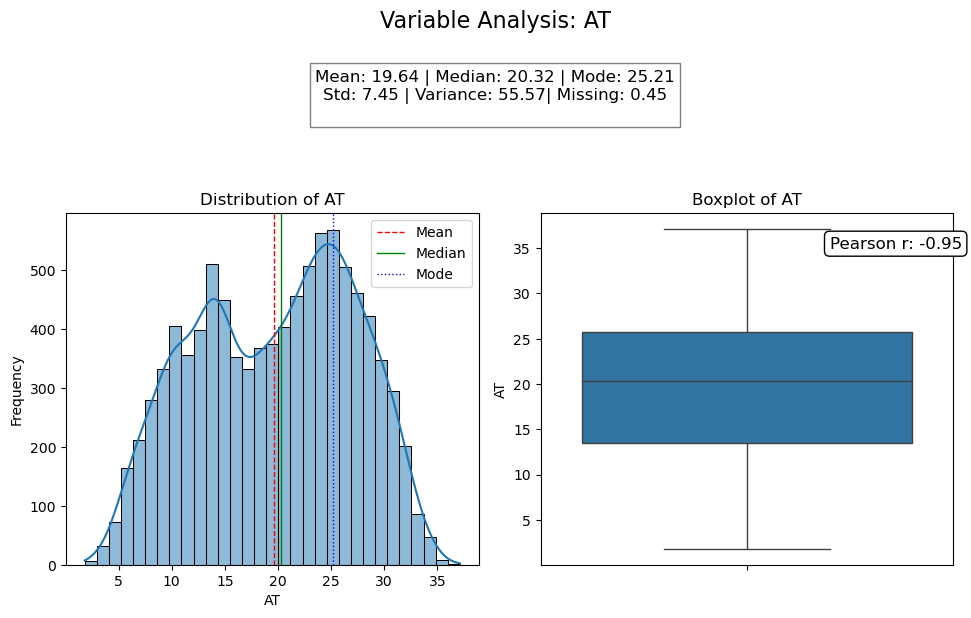

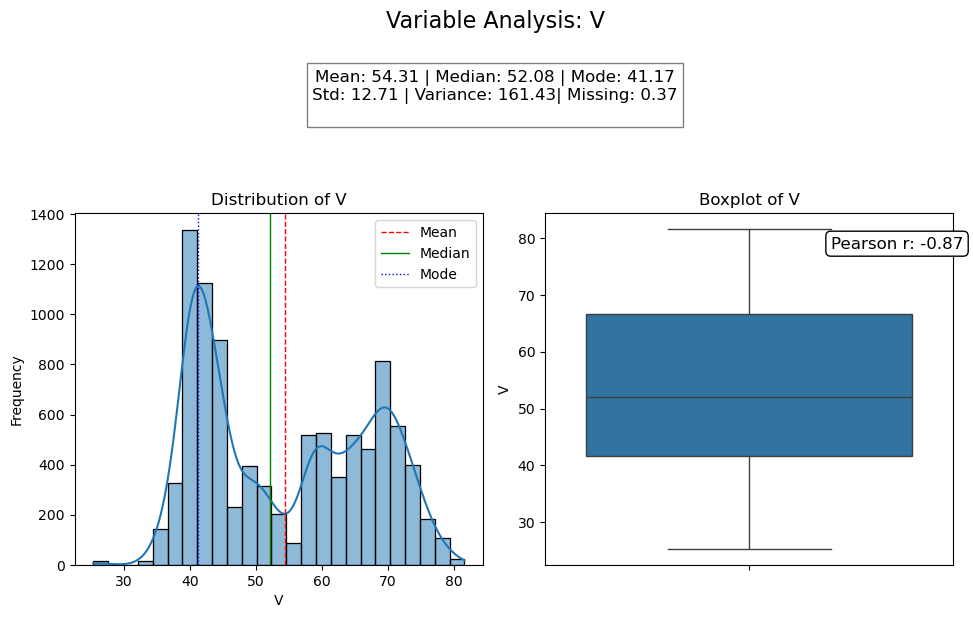

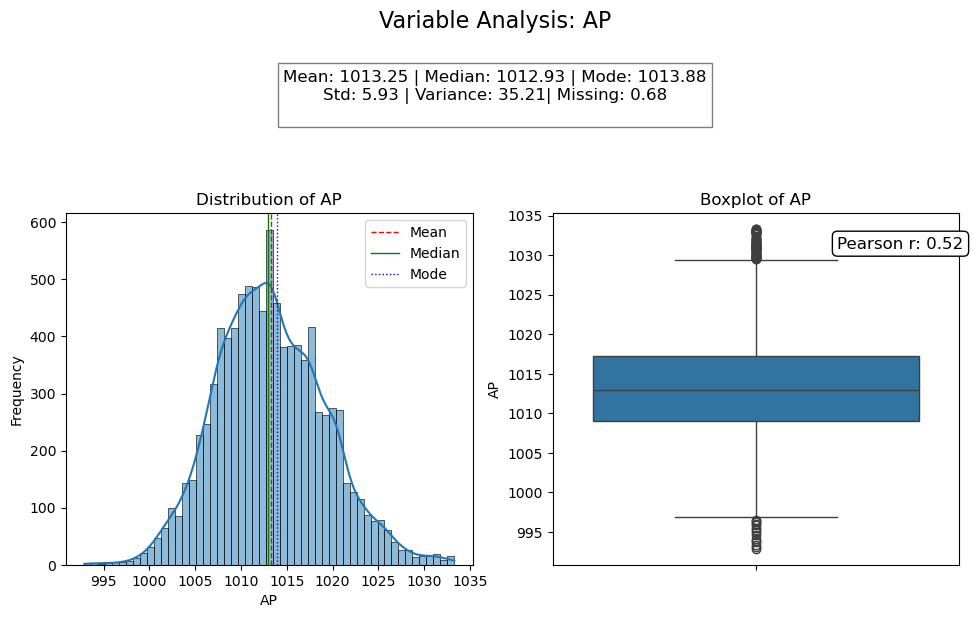

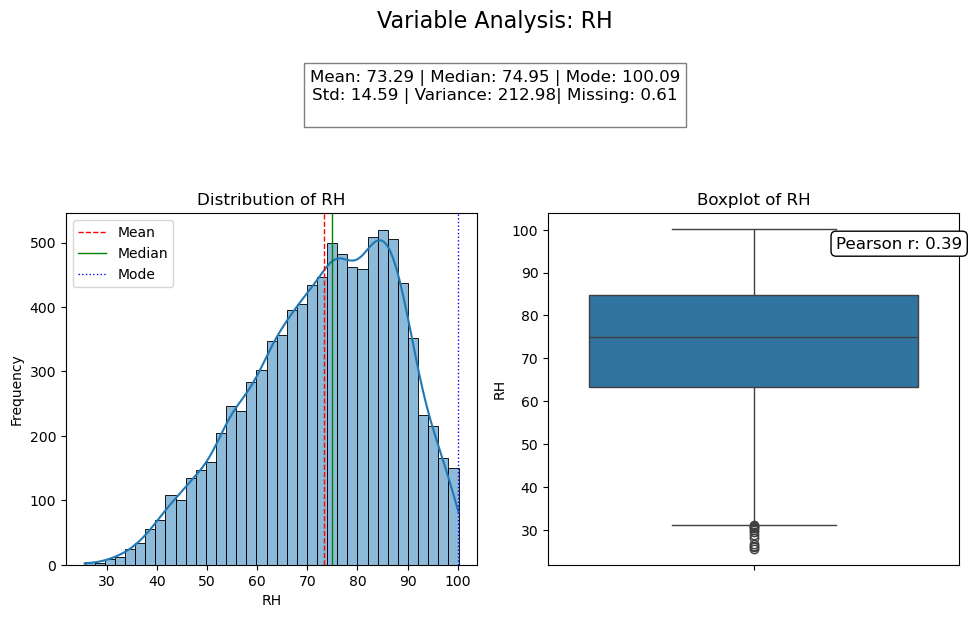

In [18]:
plot_variable_analysis(data_origin, ['AT', 'V', 'AP', 'RH'], 'PE')

## Linearity

In [19]:
data = data_origin.copy()

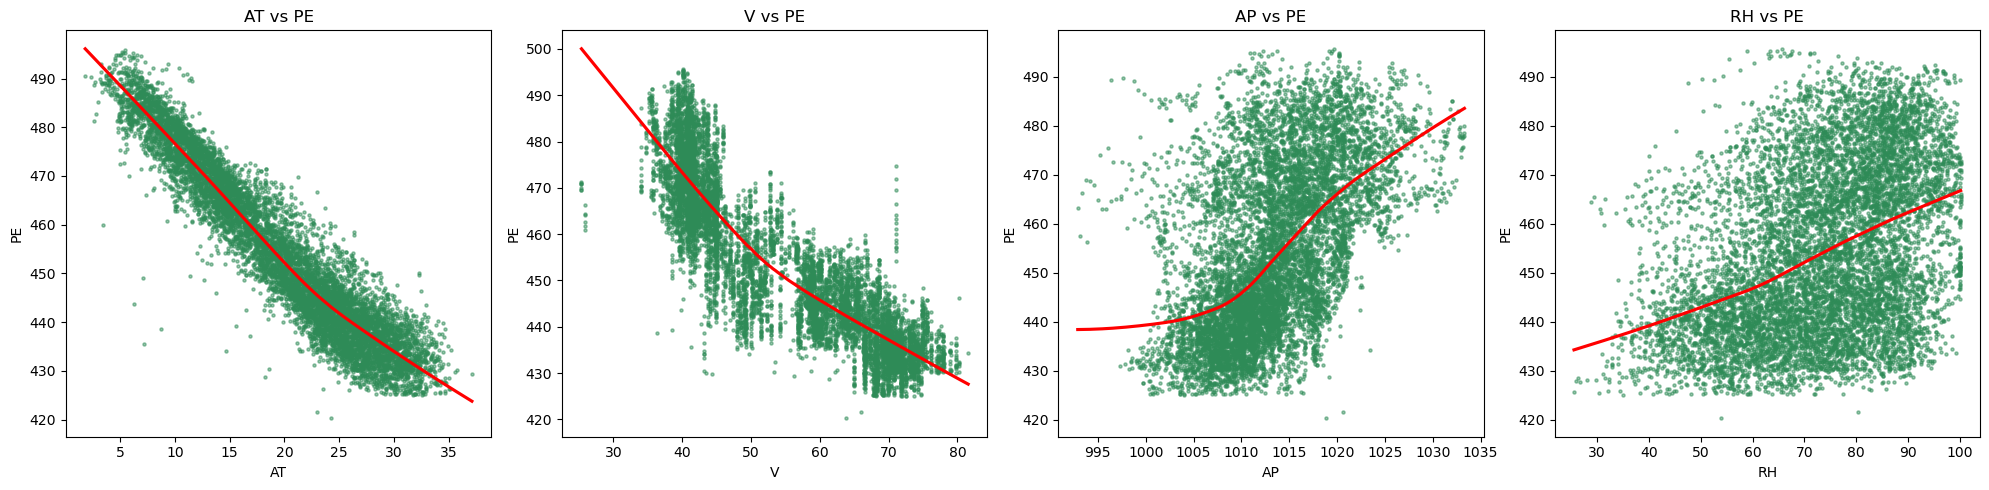

In [20]:
# Нелинейность и частичные зависимости
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(data.drop(['PE'], axis=1).columns):
    sns.regplot(
        data=data, x=col, y='PE',
        lowess=True,
        scatter_kws={'s': 5, 'alpha': 0.5, 'color': 'SeaGreen'},
        line_kws={'color': 'red'},
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs PE')

plt.tight_layout()
plt.show()

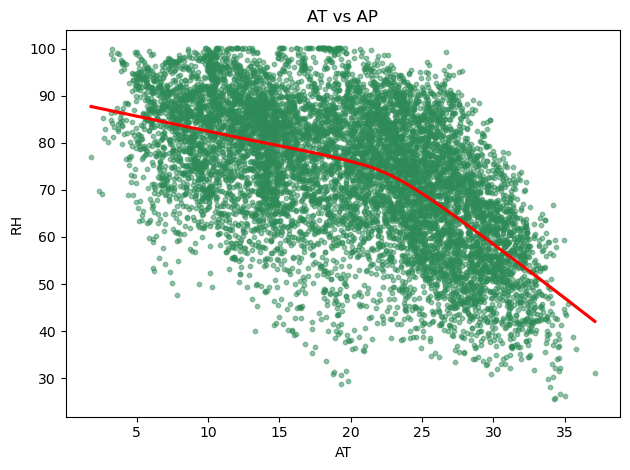

In [21]:
sns.regplot(
    data=data, x='AT', y='RH',
    lowess=True,
    scatter_kws={'s': 10, 'alpha': 0.5, 'color': 'SeaGreen'},
    line_kws={'color': 'red'}
)
plt.title(f'AT vs AP')

plt.tight_layout()
plt.show()

# Outliers

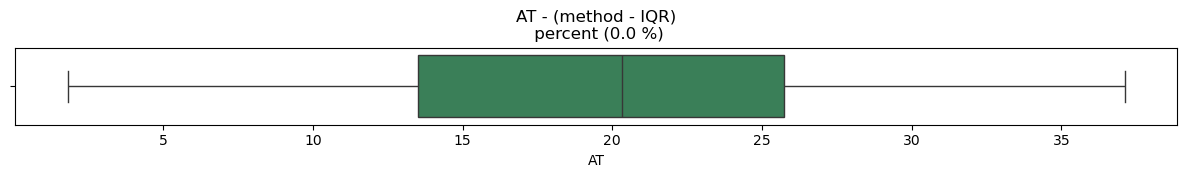

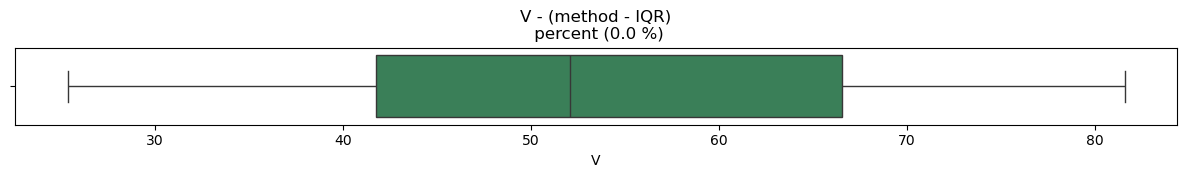

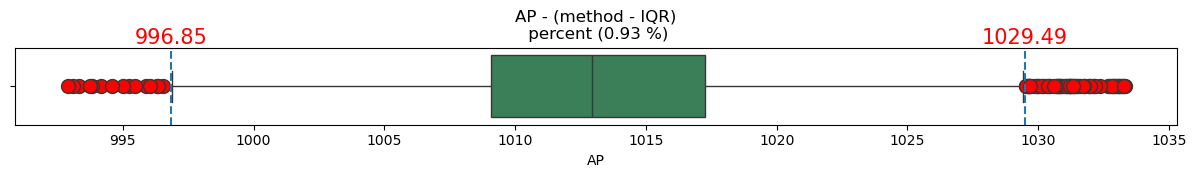

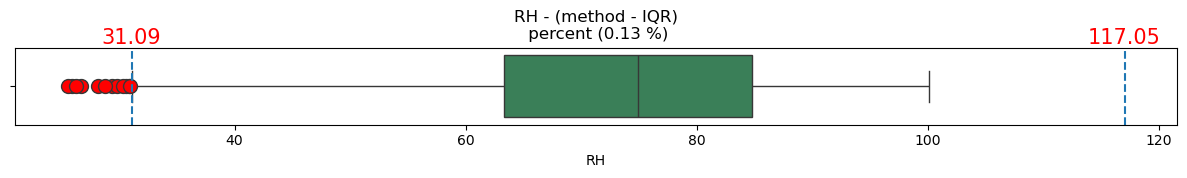

In [22]:
data_to_outliers = data_origin.drop('PE', axis=1)

for column in data_to_outliers.columns:
    plt.figure(figsize=(15, 1))
    
    # стиль для выбросов
    flier_style = dict(marker='o', markerfacecolor='r', markersize=10)
    
    # данные без NaN
    data = data_to_outliers[column].dropna()
    n = len(data)
    
    # вычисление границ выбросов по IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # выбросы
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    outlier_count = len(outliers)
    outlier_percent = round(100 * outlier_count / n, 2)
    
    # boxplot
    sns.boxplot(x=data, color='SeaGreen', flierprops=flier_style)

    if outlier_percent > 0:
        plt.axvline(lower_bound, linestyle='--')
        plt.axvline(upper_bound, linestyle='--')
        plt.text(lower_bound, -0.5, f"{lower_bound:.2f}", color='r', fontsize=15, ha='center', va='bottom')
        plt.text(upper_bound, -0.5, f"{upper_bound:.2f}", color='r', fontsize=15, ha='center', va='bottom')
    
    plt.title(f"{column} - (method - IQR)\n percent ({outlier_percent} %)")
    plt.show()

# Scaling Test

In [23]:
# Выбор числовых признаков
data_to_scale = data_origin.dropna().copy()
data_to_scale

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


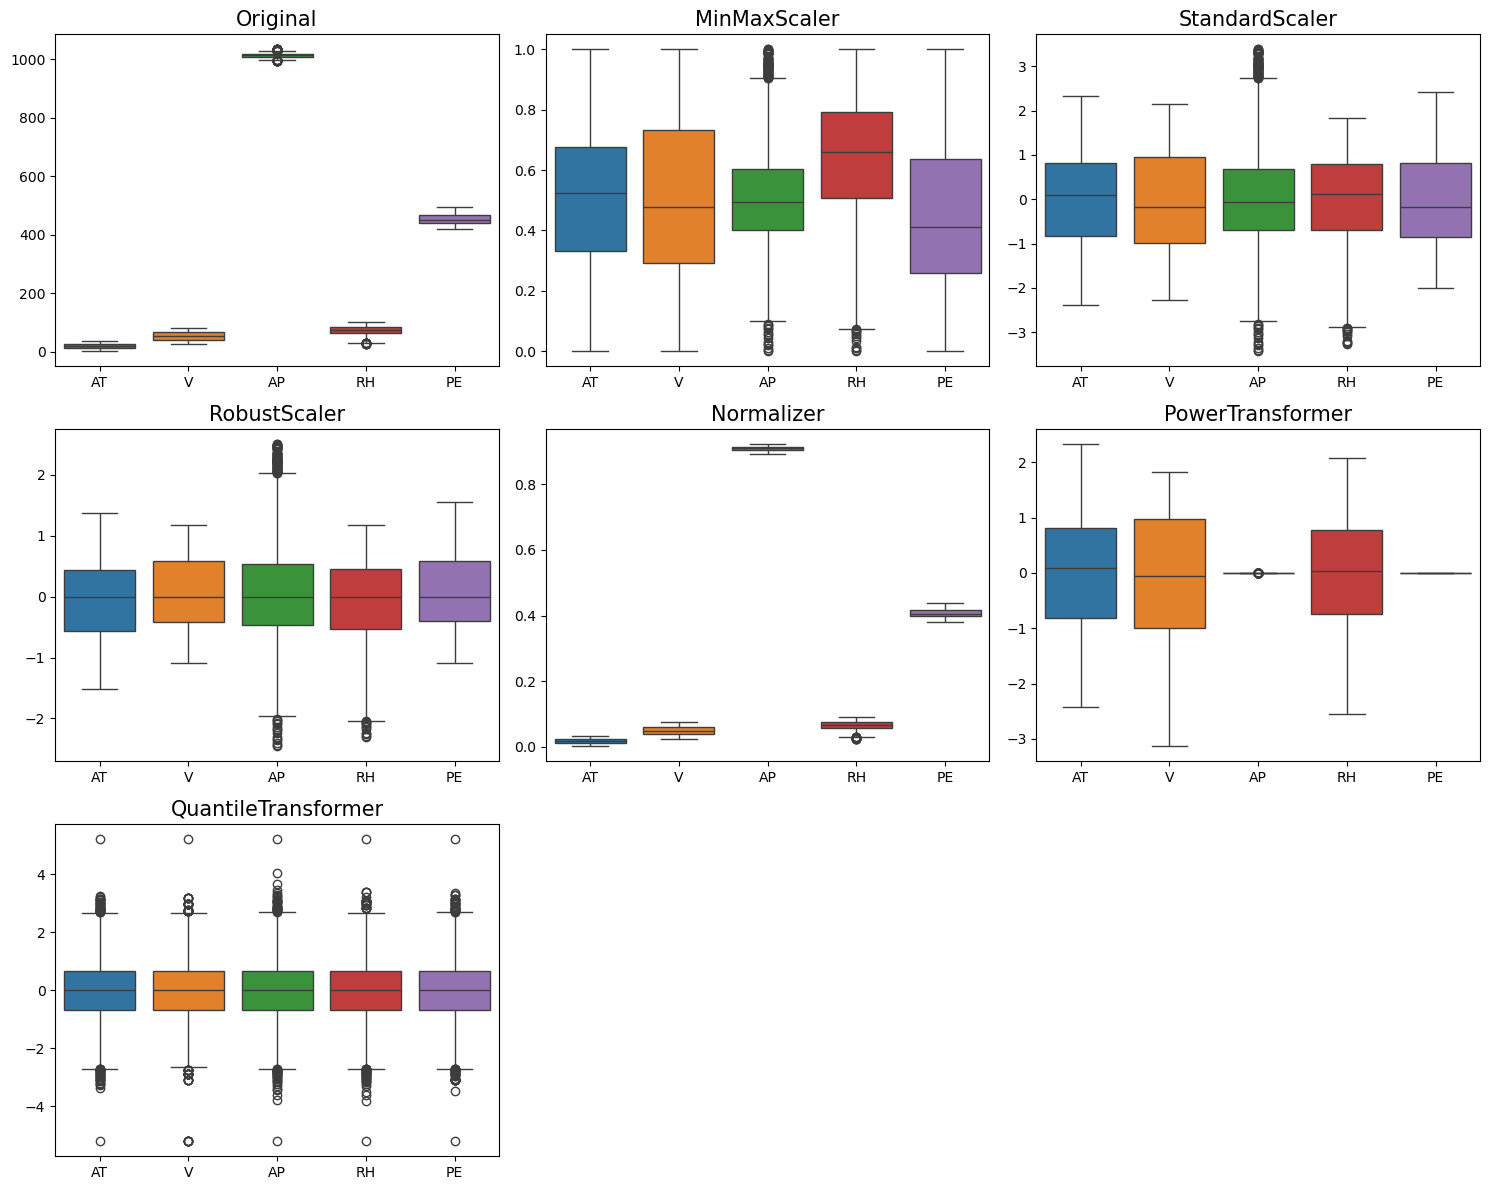

In [24]:
scalers = {
    "Original": None,
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
    "Normalizer": Normalizer(),
    "PowerTransformer": PowerTransformer(method='yeo-johnson'),
    "QuantileTransformer": QuantileTransformer(output_distribution='normal')
}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (name, scaler) in enumerate(scalers.items()):
    if scaler:
        scaled_data = scaler.fit_transform(data_to_scale)
        data1 = pd.DataFrame(scaled_data, columns=data_to_scale.columns)
    else:
        data1 = data_to_scale.copy()

    sns.boxplot(data=data1, ax=axes[i])
    axes[i].set_title(name, fontsize=15)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# OLS (Linear Regression Statistic)

In [25]:
data = data_origin.copy()
data = data.dropna()
data = data[(data.AP > 996.850) & (data.AP < 1029.490)]
data = data[(data.RH > 31.085) & (data.RH < 117.045)]
data

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


In [26]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

X = data[['AT','V','AP','RH']]
y = data['PE']

scaler = RobustScaler()
X = scaler.fit_transform(X)

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                 2.992e+04
Date:                Mon, 13 Oct 2025   Prob (F-statistic):               0.00
Time:                        19:03:15   Log-Likelihood:                -27225.
No. Observations:                9270   AIC:                         5.446e+04
Df Residuals:                    9265   BIC:                         5.450e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        452.7503      0.054   8315.104      0.0

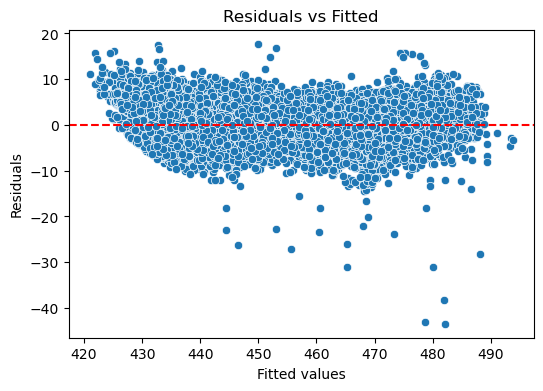

In [27]:
fitted = model.fittedvalues
residuals = model.resid
abs_residuals = np.abs(residuals)

plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

In [28]:
# 1. Создаём DataFrame с предсказаниями и остатками
results_df = data.copy()
results_df['Fitted'] = fitted
results_df['Residual'] = residuals
results_df['AbsResidual'] = abs_residuals

# 2. Фильтруем строки с ошибкой выше порога
threshold = 15  # по масштабу PE
bad_rows = results_df[results_df['AbsResidual'] > threshold]

# 3. Сортируем по убыванию ошибки
bad_rows_sorted = bad_rows.sort_values(by='AbsResidual', ascending=False)

# 4. топ-10 самых ошибочных строк
bad_rows_sorted.head(10)

,AT,V,AP,RH,PE,Fitted,Residual,AbsResidual
3117,8.74,36.30,1015.18,61.97,438.63,482.073815,-43.443815,43.443815
7664,7.14,41.22,1016.60,97.09,435.58,478.612835,-43.032835,43.032835
3383,6.22,39.85,1012.05,86.88,443.73,482.027988,-38.297988,38.297988
7398,7.06,41.74,1021.95,90.38,448.97,480.112455,-31.142455,31.142455
3895,14.69,49.64,1023.43,78.17,434.12,465.250426,-31.130426,31.130426
8362,3.40,39.64,1011.10,83.43,459.86,488.116514,-28.256514,28.256514
8187,18.26,61.27,1019.10,74.74,428.67,455.695121,-27.025121,27.025121
8717,24.27,63.87,1018.88,53.96,420.26,446.505683,-26.245683,26.245683
1438,15.61,38.52,1018.40,80.99,439.21,465.224608,-26.014608,26.014608
1568,11.41,41.40,1019.01,78.59,449.50,473.259877,-23.759877,23.759877


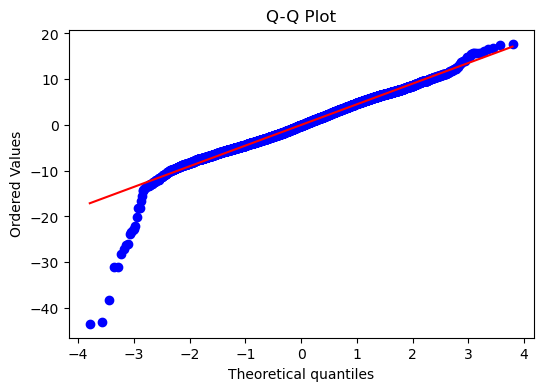

In [29]:
# нормальность остатков
plt.figure(figsize=(6,4))
stats.probplot(residuals, plot=plt)
plt.title('Q-Q Plot')
plt.show()

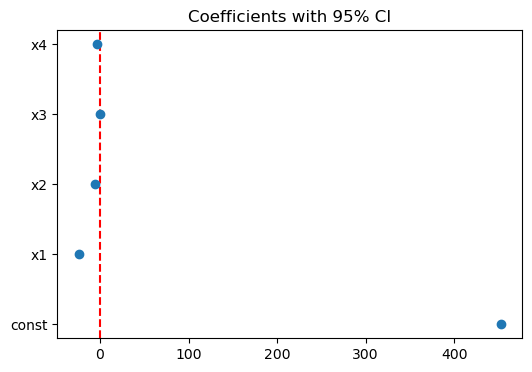

In [30]:
# значимость и направление влияния признаков
coef_df = pd.DataFrame({
    'coef': model.params,
    'lower': model.conf_int()[0],
    'upper': model.conf_int()[1]
})

plt.figure(figsize=(6,4))
plt.errorbar(coef_df['coef'], coef_df.index, 
             xerr=[coef_df['coef'] - coef_df['lower'], coef_df['upper'] - coef_df['coef']], 
             fmt='o')
plt.axvline(0, color='red', linestyle='--')
plt.title('Coefficients with 95% CI')
plt.show()

In [31]:
# VIF мультиколлинеарность
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = model.model.exog
vif_data = pd.DataFrame()
vif_data['feature'] = model.model.exog_names
vif_data['VIF'] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
print(vif_data)

  feature       VIF
0   const  1.319374
1      x1  5.899157
2      x2  3.898266
3      x3  1.443089
4      x4  1.698248


In [32]:
enginedata = data_origin.dropna()
enginedata

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


# Base Model (Linear Regression)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    enginedata.drop('PE', axis=1),
    enginedata['PE'],
    test_size=0.3,
    random_state=0
)

X_train.shape, X_test.shape

((6559, 4), (2811, 4))

In [34]:
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
def print_metrics(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{label} R²: {r2:.4f}")
    print(f"{label} MAE: {mae:.2f}")
    print(f"{label} MSE: {mse:.2f}")
    print(f"{label} RMSE: {rmse:.2f}")


Train R²: 0.9271
Train MAE: 3.63
Train MSE: 21.08
Train RMSE: 4.59

Test R²: 0.9325
Test MAE: 3.60
Test MSE: 19.95
Test RMSE: 4.47


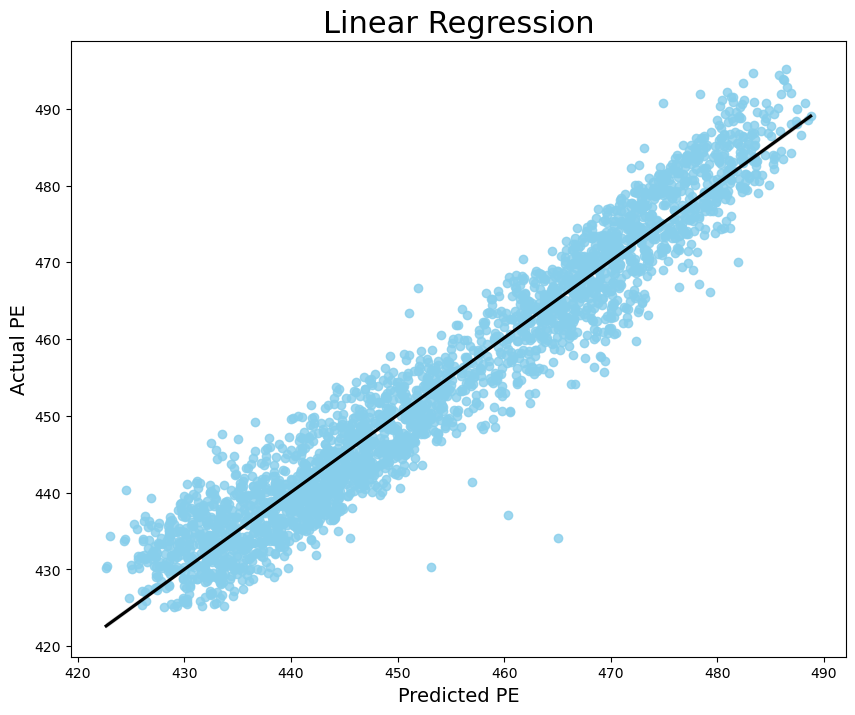

In [36]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

print_metrics(y_train, y_train_pred, "Train")
print_metrics(y_test, y_test_pred, "Test")

plt.figure(figsize=(10,8))
sns.regplot(x=y_test_pred, y=y_test, marker='o', color='skyblue', line_kws={'color':'black'})
plt.xlabel('Predicted PE', fontsize=14)
plt.ylabel('Actual PE', fontsize=14)
plt.title(f"Linear Regression", fontsize=22)
plt.show()

205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step

Train R²: 0.9339
Train MAE: 3.41
Train MSE: 19.12
Train RMSE: 4.37

Test R²: 0.9387
Test MAE: 3.38
Test MSE: 18.12
Test RMSE: 4.26


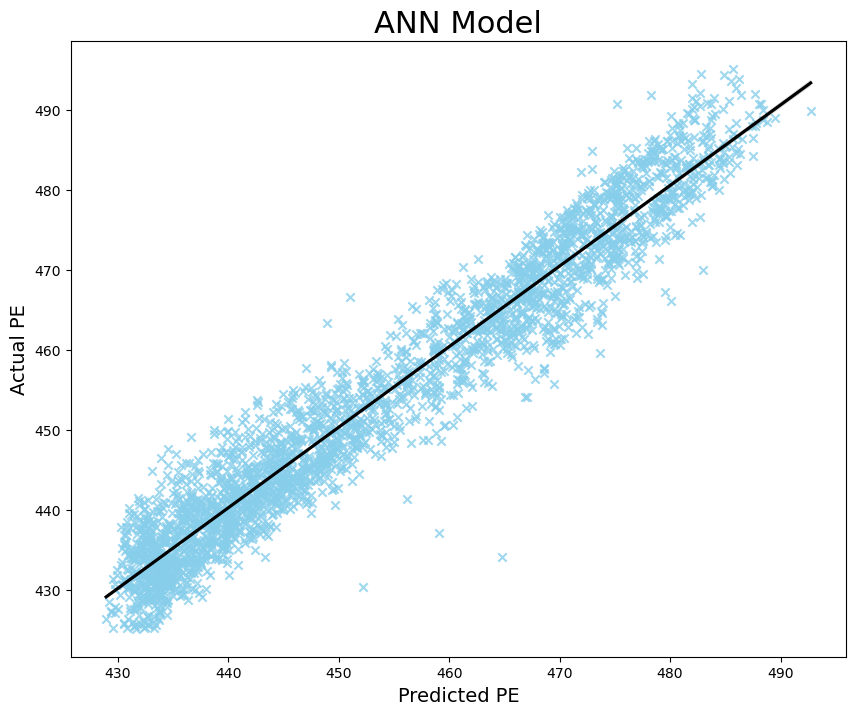

In [37]:
# ANN модель
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['r2_score'])

model.fit(X_train, y_train, batch_size=64, epochs=100, validation_data=(X_test, y_test), verbose=0)

y_train_pred = model.predict(X_train).flatten()
y_test_pred = model.predict(X_test).flatten()

print_metrics(y_train, y_train_pred, "Train")
print_metrics(y_test, y_test_pred, "Test")

plt.figure(figsize=(10,8))
sns.regplot(x=y_test_pred, y=y_test, marker='x', color='skyblue', line_kws={'color':'black'})
plt.xlabel('Predicted PE', fontsize=14)
plt.ylabel('Actual PE', fontsize=14)
plt.title("ANN Model", fontsize=22)
plt.show()


Train R²: 0.9519
Train MAE: 2.83
Train MSE: 13.92
Train RMSE: 3.73

Test R²: 0.9521
Test MAE: 2.94
Test MSE: 14.14
Test RMSE: 3.76


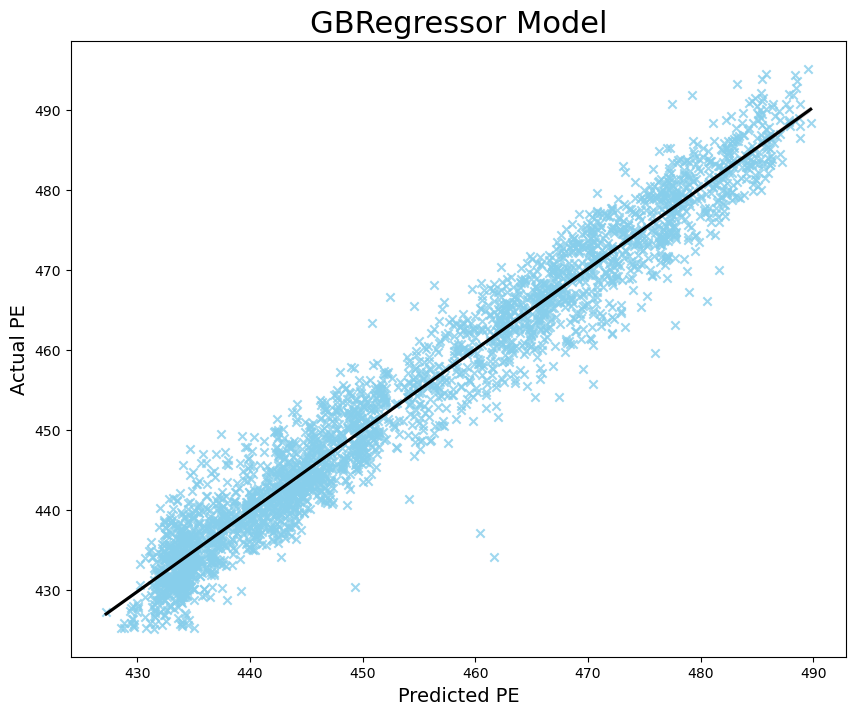

In [38]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor()

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print_metrics(y_train, y_train_pred, "Train")
print_metrics(y_test, y_test_pred, "Test")

plt.figure(figsize=(10,8))
sns.regplot(x=y_test_pred, y=y_test, marker='x', color='skyblue', line_kws={'color':'black'})
plt.xlabel('Predicted PE', fontsize=14)
plt.ylabel('Actual PE', fontsize=14)
plt.title("GBRegressor Model", fontsize=22)
plt.show()

In [39]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print("CV R²:", scores.mean())

CV R²: 0.9446181404608905


## Feature Importance

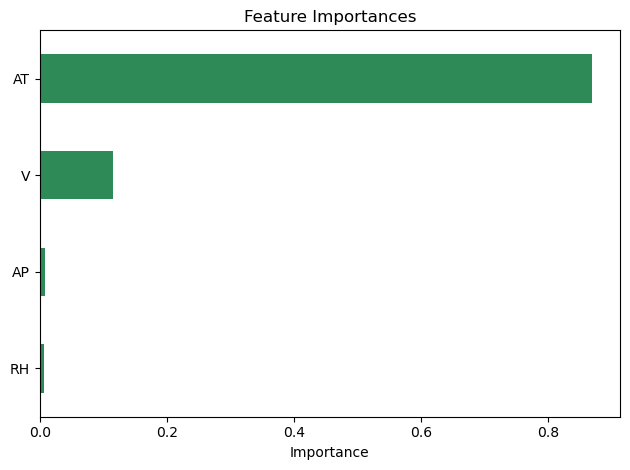

In [40]:
fi_values = model.feature_importances_
fi_series = pd.Series(fi_values, index=enginedata.drop('PE', axis=1).columns).sort_values()

fi_series.plot(kind='barh', title='Feature Importances', color='SeaGreen')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

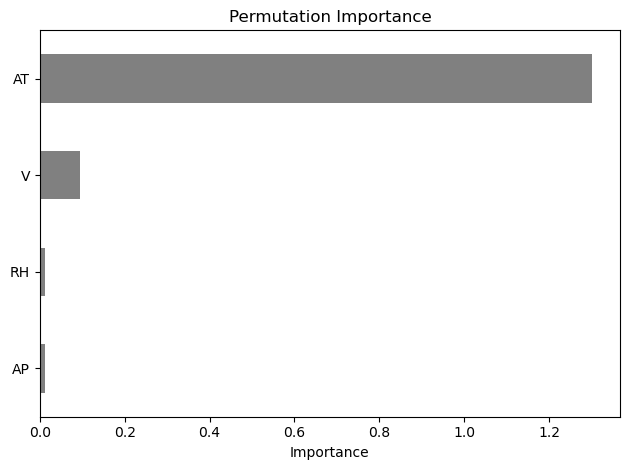

In [41]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=42)
perm_series = pd.Series(result.importances_mean, index=enginedata.drop('PE', axis=1).columns).sort_values()

perm_series.plot(kind='barh', title='Permutation Importance', color='Gray')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

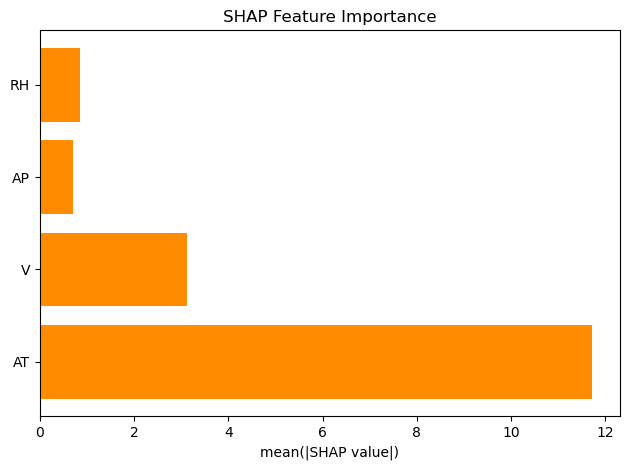

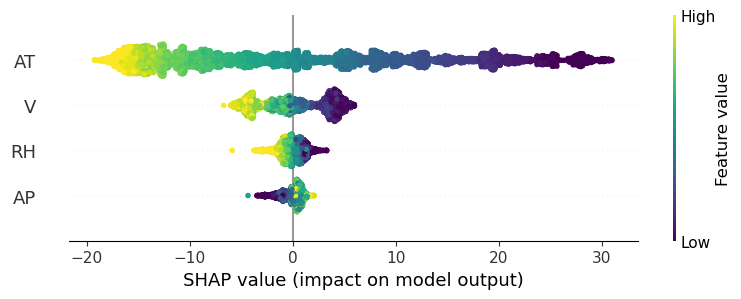

In [42]:
import shap

feature_names = ['AT', 'V', 'AP', 'RH']

explainer = shap.Explainer(model, X_train, feature_names=feature_names)
shap_values = explainer(X_train)

mean_shap = np.abs(shap_values.values).mean(axis=0)
plt.barh(feature_names, mean_shap, color="DarkOrange")
plt.xlabel("mean(|SHAP value|)")
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_train, feature_names=feature_names, cmap="viridis")